In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
df = pd.read_csv('Mall_Customers.csv')
print(df.shape)
df.head()

df.info()
df.isnull().sum()

df.drop_duplicates(inplace=True)

(200, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


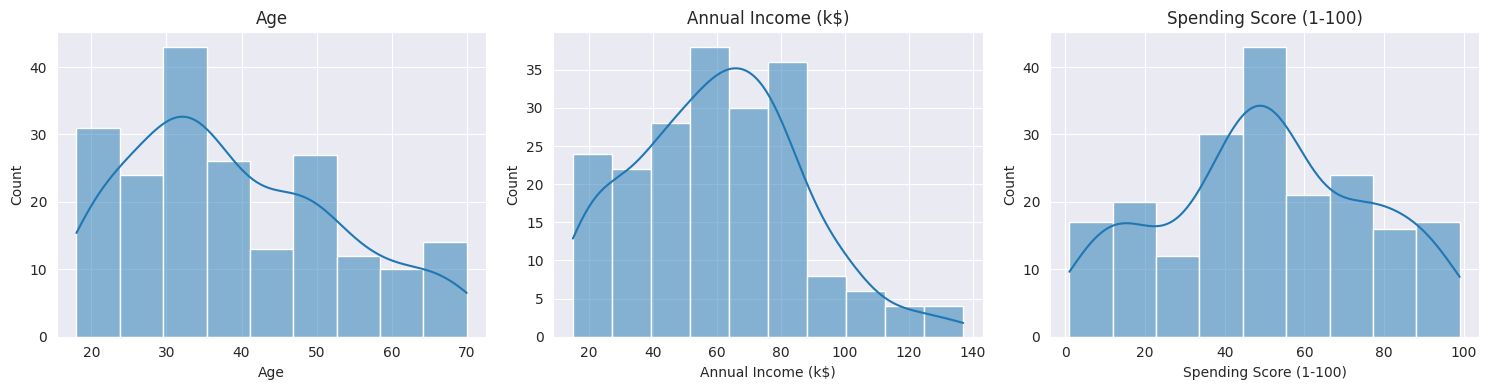

In [ ]:
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X = df[features].copy()

X.describe()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, features):
    sns.histplot(X[col], kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

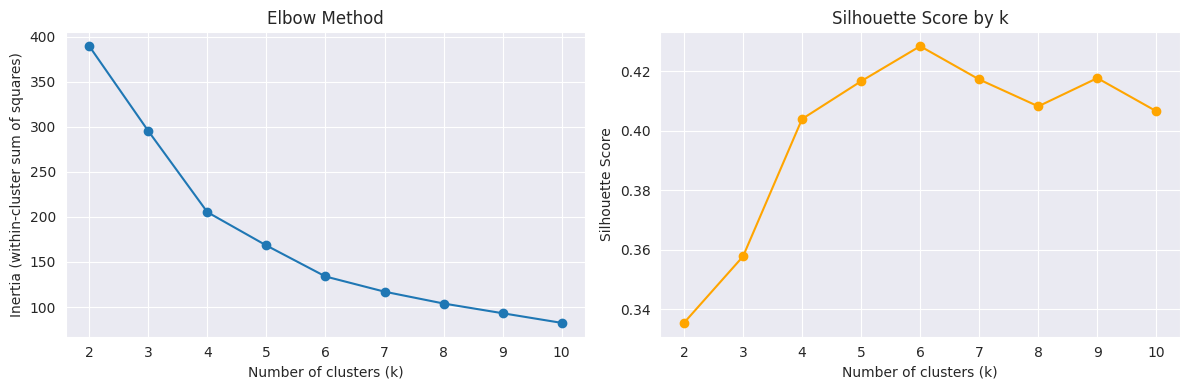

k with highest silhouette score: 6
Silhouette scores: {2: np.float64(0.3355), 3: np.float64(0.3578), 4: np.float64(0.404), 5: np.float64(0.4166), 6: np.float64(0.4284), 7: np.float64(0.4172), 8: np.float64(0.4082), 9: np.float64(0.4177), 10: np.float64(0.4066)}


In [ ]:
inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(k_range), inertias, marker='o')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia (within-cluster sum of squares)')
axes[0].set_title('Elbow Method')

axes[1].plot(list(k_range), silhouette_scores, marker='o', color='orange')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by k')

plt.tight_layout()
plt.show()

best_k_by_silhouette = list(k_range)[int(np.argmax(silhouette_scores))]
print(f"k with highest silhouette score: {best_k_by_silhouette}")
print("Silhouette scores:", dict(zip(k_range, [round(s, 4) for s in silhouette_scores])))

In [ ]:
K= 5

kmeans = KMeans(n_clusters=K, init='k-means++', random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

final_silhouette = silhouette_score(X_scaled, df['Cluster'])
print(f"Final model (k={K}) silhouette score: {final_silhouette:.4f}")

Final model (k=5) silhouette score: 0.4166


In [ ]:
cluster_summary = df.groupby('Cluster')[features].mean().round(1)
cluster_summary['Count'] = df['Cluster'].value_counts().sort_index()
print(cluster_summary)

          Age  Annual Income (k$)  Spending Score (1-100)  Count
Cluster                                                         
0        46.2                26.8                    18.4     20
1        25.2                41.1                    62.2     54
2        32.9                86.1                    81.5     40
3        39.9                86.1                    19.4     39
4        55.6                54.4                    48.9     47


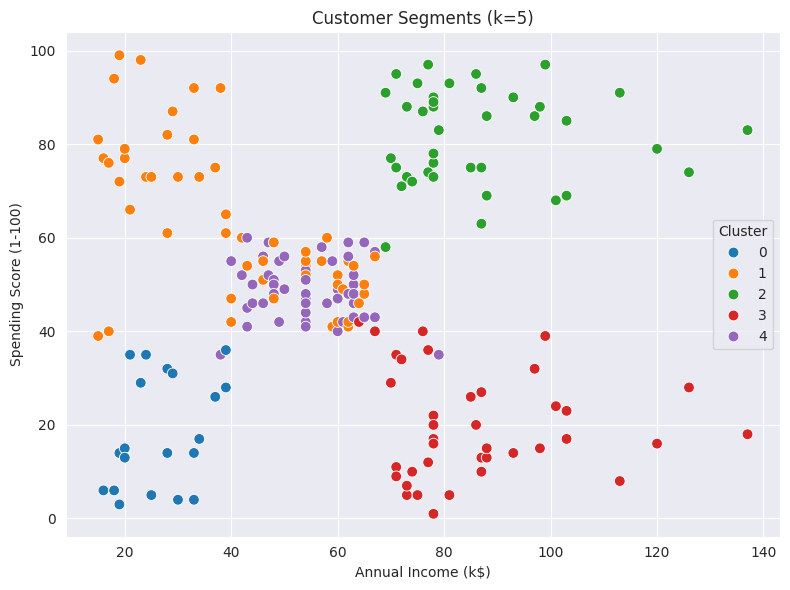

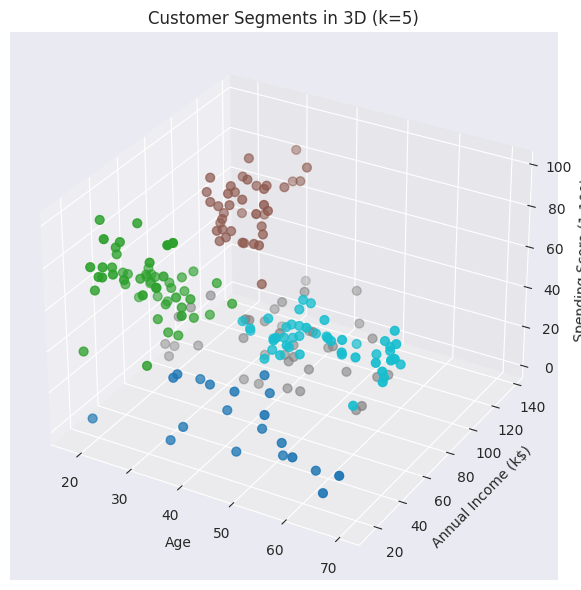

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df, x='Annual Income (k$)', y='Spending Score (1-100)',
    hue='Cluster', palette='tab10', s=60
)
plt.title(f'Customer Segments (k={K})')
plt.tight_layout()
plt.show()

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection='3d')
scatter = ax.scatter(
    df['Age'], df['Annual Income (k$)'], df['Spending Score (1-100)'],
    c=df['Cluster'], cmap='tab10', s=40
)
ax.set_xlabel('Age')
ax.set_ylabel('Annual Income (k$)')
ax.set_zlabel('Spending Score (1-100)')
ax.set_title(f'Customer Segments in 3D (k={K})')
plt.tight_layout()
plt.show()